Tutorial 3 (CH-4124)

####
Fitting chemical data
From raw numbers to a physical parameter: least squares, nonlinear fits, and log-linearisation.
####

### 1. NumPy warm-up and vectorised chemistry

Build arrays, apply the Beer-Lambert law elementwise, and add measurement noise.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Concentration grid (mol/L)
c = np.linspace(0.0, 1.0e-3, 25)          # TO DO: np.linspace(0.0, 1.0e-3, 25)

epsilon = 8500.0    # TO DO: molar absorptivity, e.g., 8500.0 (L/mol/cm)
path_len = 1.0   # TO DO: cuvette path length in cm, e.g., 1.0

# Beer-Lambert: A = epsilon * l * c
A_true = epsilon * path_len * c     # TO DO: vectorised expression, no loop

# Add gaussian noise to mimic a real spectrometer
noise = rng.normal(loc=0.0, scale=0.02, size=c.size)   # TO DO: scale e.g. 0.02
A_obs = A_true + noise      # TO DO: A_true + noise

print("shape:", A_obs.shape, "| max A:", A_obs.max().round(3))
print("mean:", A_obs.mean().round(3), "| std:", A_obs.std().round(3))   # TO DO: A_obs.mean(), A_obs.std()

shape: (25,) | max A: 8.518
mean: 4.249 | std: 2.555


### 2. Straight-line least squares

Fit A vs c, recover the molar absorptivity, and judge the fit quality with R-squared.

slope (eps*l): 8503.705194110798
recovered epsilon: 8503.71
intercept: -0.003 | R2: 1.0


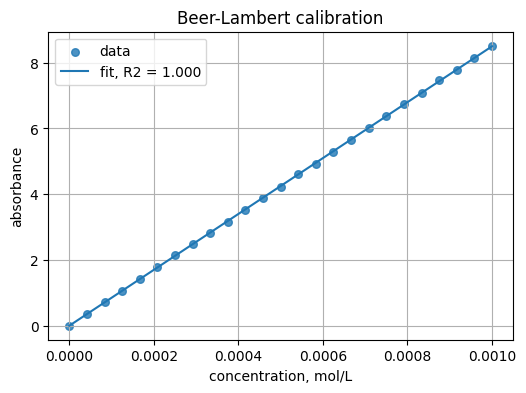

In [2]:
# Fit a first degree polynomial: A = m*c + b
coeffs = np.polyfit(c, A_obs, 1)        # TO DO: np.polyfit(c, A_obs, 1)
m, b = coeffs          # TO DO: unpack coeffs

A_fit = np.polyval(coeffs, c)         # TO DO: np.polyval(coeffs, c)

# R-squared
ss_res = np.sum((A_obs - A_fit)**2)        # TO DO: np.sum((A_obs - A_fit)**2)
ss_tot = np.sum((A_obs - A_obs.mean())**2)        # TO DO: np.sum((A_obs - A_obs.mean())**2)
r2 = 1 - ss_res/ss_tot            # TO DO: 1 - ss_res/ss_tot

print("slope (eps*l):", m)
print("recovered epsilon:", (m / path_len).round(2))     # TO DO: m / path_len
print("intercept:", b.round(3), "| R2:", r2.round(3))

plt.figure(figsize=(6, 4))
plt.scatter(c, A_obs, s=30, alpha=0.8, label="data")     # TO DO: e.g. 30, 0.8
plt.plot(c, A_fit, "-", label=f"fit, R2 = {r2:.3f}")
plt.xlabel("concentration, mol/L")
plt.ylabel("absorbance")
plt.title("Beer-Lambert calibration")
plt.legend()
plt.grid(True)

### 3. Residuals

A fit is only as good as its residuals. Plot them and look for structure.

mean residual: 0.0
RMSE: 0.017


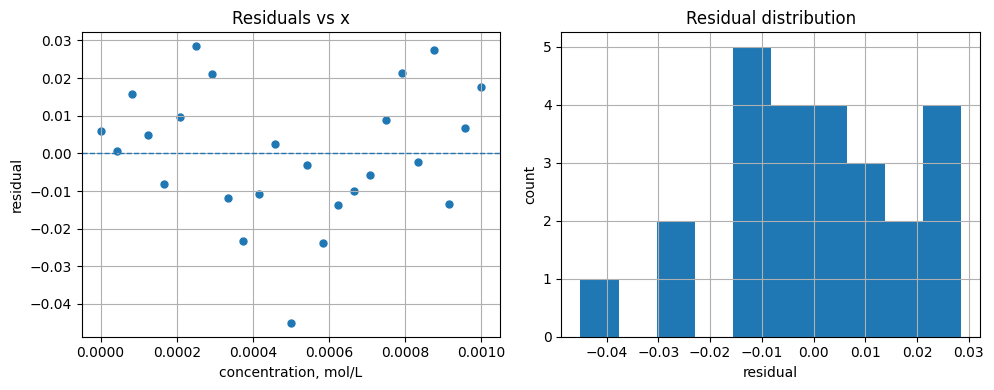

In [3]:
resid = A_obs - A_fit      # TO DO: A_obs - A_fit

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(c, resid, s=25)        # TO DO: c, resid
axes[0].axhline(0.0, ls="--", lw=1)
axes[0].set_xlabel("concentration, mol/L")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs x")
axes[0].grid(True)

axes[1].hist(resid, bins=10)            # TO DO: resid, e.g. 10
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title("Residual distribution")
axes[1].grid(True)

plt.tight_layout()

print("mean residual:", resid.mean().round(3))           # TO DO: resid.mean()
print("RMSE:", np.sqrt(np.mean(resid**2)).round(3))                    # TO DO: np.sqrt(np.mean(resid**2))

### 4. Nonlinear fit — first order kinetics

A decays as [A] = [A]0 * exp(-k t). Fit it directly with `curve_fit`, then compare
against the linearised form ln[A] vs t.

A0 = 0.8494 +/- 0.0067
k  = 0.04468 +/- 0.00055 1/min
half life, min: 15.514850010491944


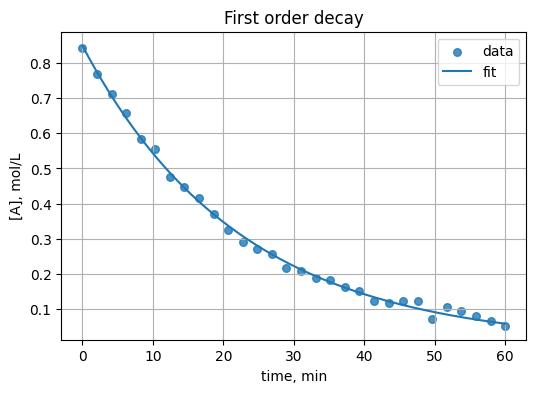

In [27]:
from scipy.optimize import curve_fit

# Synthetic kinetics run
t = np.linspace(0.0, 60.0, 30)          # minutes
A0_true, k_true = 0.85, 0.045
conc = A0_true*np.exp(-k_true*t) + rng.normal(0.0, 0.015, t.size)

def first_order(t, A0, k):
    return A0*np.exp(-k*t)                          # TO DO: A0*np.exp(-k*t)

p0 = [1.0, 0.01]                                # TO DO: initial guess, e.g. [1.0, 0.01]
popt, pcov = curve_fit(first_order, t, conc, p0=p0)                        # TO DO: curve_fit(first_order, t, conc, p0=p0)

A0_fit, k_fit = popt                     # TO DO: unpack popt
perr = np.sqrt(np.diag(pcov))                              # TO DO: np.sqrt(np.diag(pcov))

print(f"A0 = {A0_fit:.4f} +/- {perr[0]:.4f}")
print(f"k  = {k_fit:.5f} +/- {perr[1]:.5f} 1/min")
print("half life, min:", np.log(2)/k_fit)           # TO DO: np.log(2)/k_fit

t_smooth = np.linspace(t.min(), t.max(), 200)

plt.figure(figsize=(6, 4))
plt.scatter(t, conc, s=30, alpha=0.8, label="data")
plt.plot(t_smooth, first_order(t_smooth, *popt), "-", label="fit")   # TO DO: first_order(t_smooth, *popt)
plt.xlabel("time, min")
plt.ylabel("[A], mol/L")
plt.title("First order decay")
plt.legend()
plt.grid(True)

k from linearisation: 0.04469
k from curve_fit    : 0.04342


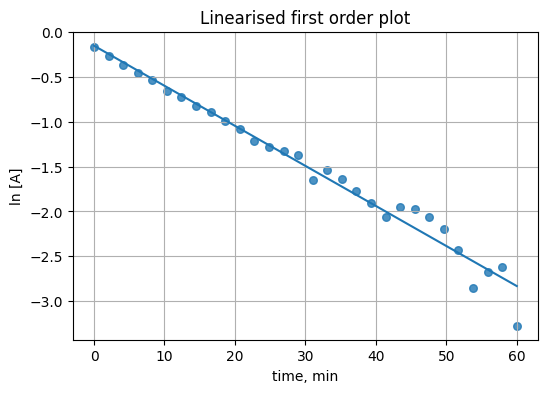

In [5]:
# Linearised check: ln[A] should be straight with slope -k
mask = conc > 0                    # guard against log of a negative noisy point
ln_c = np.log(conc[mask])                         # TO DO: np.log(conc[mask])

slope, intercept = np.polyfit(t[mask], ln_c, 1)             # TO DO: np.polyfit(t[mask], ln_c, 1)
print("k from linearisation:", -slope.round(5))   # TO DO: -slope
print("k from curve_fit    :", k_fit.round(5))

plt.figure(figsize=(6, 4))
plt.scatter(t[mask], ln_c, s=30, alpha=0.8)
plt.plot(t[mask], np.polyval([slope, intercept], t[mask]), "-")        # TO DO: np.polyval([slope, intercept], t[mask])
plt.xlabel("time, min")
plt.ylabel("ln [A]")
plt.title("Linearised first order plot")
plt.grid(True)

In [25]:
import pandas as pd
import numpy as np

# Generate synthetic data for arrhenius_rates.csv
rng = np.random.default_rng(0)

data = {
    'run_id': [],
    'temperature_K': [],
    'rate_constant': [],
    'catalyst': []
}

catalysts = ['A', 'B', 'C']

for cat in catalysts:
    for _ in range(10): # 10 data points per catalyst
        temp_K = rng.uniform(280, 350) # Temperature between 280K and 350K
        # Simulate Arrhenius behavior: k = A * exp(-Ea / (R * T))
        # Use different Ea and A for each catalyst
        if cat == 'A':
            Ea = 50000  # J/mol
            A = 1e8     # pre-exponential factor
        elif cat == 'B':
            Ea = 60000
            A = 2e8
        else:
            Ea = 45000
            A = 5e7

        R_gas = 8.314 # J/mol/K
        true_k = A * np.exp(-Ea / (R_gas * temp_K))
        rate_constant = true_k * (1 + rng.normal(0, 0.1)) # Add some noise

        data['run_id'].append(len(data['run_id']) + 1)
        data['temperature_K'].append(temp_K)
        data['rate_constant'].append(max(0, rate_constant)) # Ensure rate is non-negative
        data['catalyst'].append(cat)

df_arrhenius = pd.DataFrame(data)
df_arrhenius.to_csv('arrhenius_rates.csv', index=False)
print("Generated arrhenius_rates.csv")
print(df_arrhenius.head())

Generated arrhenius_rates.csv
   run_id  temperature_K  rate_constant catalyst
0       1     324.587318       0.886377        A
1       2     282.868147       0.059042        A
2       3     336.928917       1.834700        A
3       4     322.464504       0.870403        A
4       5     318.053749       0.536216        A


In [23]:
import pandas as pd
import numpy as np

# Generate synthetic data for arrhenius_rates.csv
rng = np.random.default_rng(0)

data = {
    'run_id': [],
    'temperature_K': [],
    'rate_constant': [],
    'catalyst': []
}

catalysts = ['A', 'B', 'C']

for cat in catalysts:
    for _ in range(10): # 10 data points per catalyst
        temp_K = rng.uniform(280, 350) # Temperature between 280K and 350K
        # Simulate Arrhenius behavior: k = A * exp(-Ea / (R * T))
        # Use different Ea and A for each catalyst
        if cat == 'A':
            Ea = 50000  # J/mol
            A = 1e8     # pre-exponential factor
        elif cat == 'B':
            Ea = 60000
            A = 2e8
        else:
            Ea = 45000
            A = 5e7

        R_gas = 8.314 # J/mol/K
        true_k = A * np.exp(-Ea / (R_gas * temp_K))
        rate_constant = true_k * (1 + rng.normal(0, 0.1)) # Add some noise

        data['run_id'].append(len(data['run_id']) + 1)
        data['temperature_K'].append(temp_K)
        data['rate_constant'].append(max(0, rate_constant)) # Ensure rate is non-negative
        data['catalyst'].append(cat)

df_arrhenius = pd.DataFrame(data)
df_arrhenius.to_csv('arrhenius_rates.csv', index=False)
print("Generated arrhenius_rates.csv")
print(df_arrhenius.head())

Generated arrhenius_rates.csv
   run_id  temperature_K  rate_constant catalyst
0       1     324.587318       0.886377        A
1       2     282.868147       0.059042        A
2       3     336.928917       1.834700        A
3       4     322.464504       0.870403        A
4       5     318.053749       0.536216        A


In [21]:
import pandas as pd
import numpy as np

# Generate synthetic data for arrhenius_rates.csv
rng = np.random.default_rng(0)

data = {
    'run_id': [],
    'temperature_K': [],
    'rate_constant': [],
    'catalyst': []
}

catalysts = ['A', 'B', 'C']

for cat in catalysts:
    for _ in range(10): # 10 data points per catalyst
        temp_K = rng.uniform(280, 350) # Temperature between 280K and 350K
        # Simulate Arrhenius behavior: k = A * exp(-Ea / (R * T))
        # Use different Ea and A for each catalyst
        if cat == 'A':
            Ea = 50000  # J/mol
            A = 1e8     # pre-exponential factor
        elif cat == 'B':
            Ea = 60000
            A = 2e8
        else:
            Ea = 45000
            A = 5e7

        R_gas = 8.314 # J/mol/K
        true_k = A * np.exp(-Ea / (R_gas * temp_K))
        rate_constant = true_k * (1 + rng.normal(0, 0.1)) # Add some noise

        data['run_id'].append(len(data['run_id']) + 1)
        data['temperature_K'].append(temp_K)
        data['rate_constant'].append(max(0, rate_constant)) # Ensure rate is non-negative
        data['catalyst'].append(cat)

df_arrhenius = pd.DataFrame(data)
df_arrhenius.to_csv('arrhenius_rates.csv', index=False)
print("Generated arrhenius_rates.csv")
print(df_arrhenius.head())

Generated arrhenius_rates.csv
   run_id  temperature_K  rate_constant catalyst
0       1     324.587318       0.886377        A
1       2     282.868147       0.059042        A
2       3     336.928917       1.834700        A
3       4     322.464504       0.870403        A
4       5     318.053749       0.536216        A


In [13]:
import pandas as pd
import numpy as np

# Generate synthetic data for arrhenius_rates.csv
rng = np.random.default_rng(0)

data = {
    'run_id': [],
    'temperature_K': [],
    'rate_constant': [],
    'catalyst': []
}

catalysts = ['A', 'B', 'C']

for cat in catalysts:
    for _ in range(10): # 10 data points per catalyst
        temp_K = rng.uniform(280, 350) # Temperature between 280K and 350K
        # Simulate Arrhenius behavior: k = A * exp(-Ea / (R * T))
        # Use different Ea and A for each catalyst
        if cat == 'A':
            Ea = 50000  # J/mol
            A = 1e8     # pre-exponential factor
        elif cat == 'B':
            Ea = 60000
            A = 2e8
        else:
            Ea = 45000
            A = 5e7

        R_gas = 8.314 # J/mol/K
        true_k = A * np.exp(-Ea / (R_gas * temp_K))
        rate_constant = true_k * (1 + rng.normal(0, 0.1)) # Add some noise

        data['run_id'].append(len(data['run_id']) + 1)
        data['temperature_K'].append(temp_K)
        data['rate_constant'].append(max(0, rate_constant)) # Ensure rate is non-negative
        data['catalyst'].append(cat)

df_arrhenius = pd.DataFrame(data)
df_arrhenius.to_csv('arrhenius_rates.csv', index=False)
print("Generated arrhenius_rates.csv")
print(df_arrhenius.head())

Generated arrhenius_rates.csv
   run_id  temperature_K  rate_constant catalyst
0       1     324.587318       0.886377        A
1       2     282.868147       0.059042        A
2       3     336.928917       1.834700        A
3       4     322.464504       0.870403        A
4       5     318.053749       0.536216        A


### 5. New dataset — Arrhenius rate constants

Work with `arrhenius_rates.csv`, columns `run_id`, `temperature_K`, `rate_constant`, `catalyst`.
Tasks:

Read the CSV and inspect it
Add columns for 1/T and ln k
Fit ln k vs 1/T for each catalyst separately
Report Ea in kJ/mol and the pre-exponential factor A
Overlay both fits on one plot

In [15]:
import pandas as pd

path = "arrhenius_rates.csv"

df = pd.read_csv(path)                 # TO DO: pd.read_csv(path)
print(df.head())
print(df.info())
print(df["catalyst"].value_counts())

# Derived columns
df["inv_T"] = 1.0 / df["temperature_K"]        # TO DO: 1.0 / df["temperature_K"]
df["ln_k"]  = np.log(df["rate_constant"])        # TO DO: np.log(df["rate_constant"])

df.head()

   run_id  temperature_K  rate_constant catalyst
0       1     324.587318       0.886377        A
1       2     282.868147       0.059042        A
2       3     336.928917       1.834700        A
3       4     322.464504       0.870403        A
4       5     318.053749       0.536216        A
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   run_id         30 non-null     int64  
 1   temperature_K  30 non-null     float64
 2   rate_constant  30 non-null     float64
 3   catalyst       30 non-null     object 
dtypes: float64(2), int64(1), object(1)
memory usage: 1.1+ KB
None
catalyst
A    10
B    10
C    10
Name: count, dtype: int64


,run_id,temperature_K,rate_constant,catalyst,inv_T,ln_k
0,1,324.587318,0.886377,A,0.003081,-0.120613
1,2,282.868147,0.059042,A,0.003535,-2.829505
2,3,336.928917,1.834700,A,0.002968,0.606881
3,4,322.464504,0.870403,A,0.003101,-0.138799
4,5,318.053749,0.536216,A,0.003144,-0.623219


In [16]:
R = 8.314   # J/mol/K

results = {}

for cat, grp in df.groupby("catalyst"):                       # TO DO: df.groupby("catalyst")
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()                                # TO DO: grp["ln_k"].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)                 # TO DO: np.polyfit(x, y, 1)

    Ea_kJ = -slope * R / 1000.0                            # TO DO: -slope * R / 1000.0
    A_pre = np.exp(intercept)                            # TO DO: np.exp(intercept)

    results[cat] = {"slope": slope, "intercept": intercept,
                    "Ea_kJ_per_mol": Ea_kJ, "A": A_pre, "n": len(grp)}

    print(f"{cat:>12} | Ea = {Ea_kJ:7.2f} kJ/mol | A = {A_pre:.3e} | n = {len(grp)}")

summary = pd.DataFrame(results).T
summary

           A | Ea =   49.24 kJ/mol | A = 7.500e+07 | n = 10
           B | Ea =   58.84 kJ/mol | A = 1.330e+08 | n = 10
           C | Ea =   43.72 kJ/mol | A = 3.193e+07 | n = 10


,slope,intercept,Ea_kJ_per_mol,A,n
A,-5922.448311,18.132944,49.239235,7.499594e+07,10.0
B,-7077.257770,18.705560,58.840321,1.329601e+08,10.0
C,-5258.866119,17.279190,43.722213,3.193426e+07,10.0


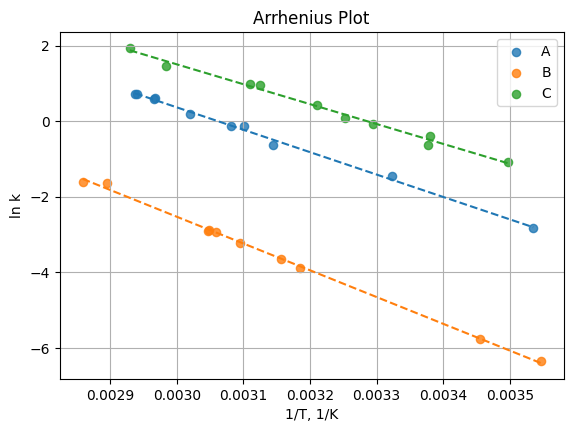

In [17]:
plt.figure(figsize=(6.5, 4.5))

for cat, grp in df.groupby("catalyst"):
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()
    plt.scatter(x, y, s=35, alpha=0.8, label=cat)          # TO DO: e.g. 35, 0.8

    fit = results[cat]
    xs = np.linspace(x.min(), x.max(), 50)
    plt.plot(xs, fit["slope"]*xs + fit["intercept"], "--")                                  # TO DO: fit["slope"]*xs + fit["intercept"]

plt.xlabel("1/T, 1/K")
plt.ylabel("ln k")
plt.title("Arrhenius Plot")                                               # TO DO: give it a title
plt.legend()
plt.grid(True)                                                # TO DO

### 6. Messy data

Real files have blanks and outliers. Clean before fitting.

In [18]:
# How many missing values per column?
print(df.isna().sum())                        # TO DO: df.isna().sum()

# Drop rows missing the rate constant
df_clean = df.dropna(subset=["rate_constant"]).copy()                    # TO DO: df.dropna(subset=["rate_constant"]).copy()
print("rows before:", len(df), "| after:", len(df_clean))

# Flag outliers with a z-score on ln k, per catalyst
z = df_clean.groupby("catalyst")["ln_k"].transform(lambda s: (s - s.mean()) / s.std())
df_clean["is_outlier"] = z.abs() > 2.5      # TO DO: z.abs() > 2.5
print(df_clean["is_outlier"].sum(), "outliers flagged")

df_ok = df_clean[~df_clean["is_outlier"]]                       # TO DO: df_clean[~df_clean["is_outlier"]]

# Refit one catalyst with and without outliers and compare Ea
cat = 'A'                         # TO DO: pick a catalyst name from the file
sub_all = df_clean[df_clean["catalyst"] == cat]
sub_ok  = df_ok[df_ok["catalyst"] == cat]

for name, sub in [("with outliers", sub_all), ("cleaned", sub_ok)]:
    s, _ = np.polyfit(sub["inv_T"], sub["ln_k"], 1)
    print(f"{name:>14}: Ea = {-s*R/1000:.2f} kJ/mol")

run_id           0
temperature_K    0
rate_constant    0
catalyst         0
inv_T            0
ln_k             0
dtype: int64
rows before: 30 | after: 30
0 outliers flagged
 with outliers: Ea = 49.24 kJ/mol
       cleaned: Ea = 49.24 kJ/mol


### 7. Publication-style figure

Two panels side by side, shared styling, saved to disk at 300 dpi.

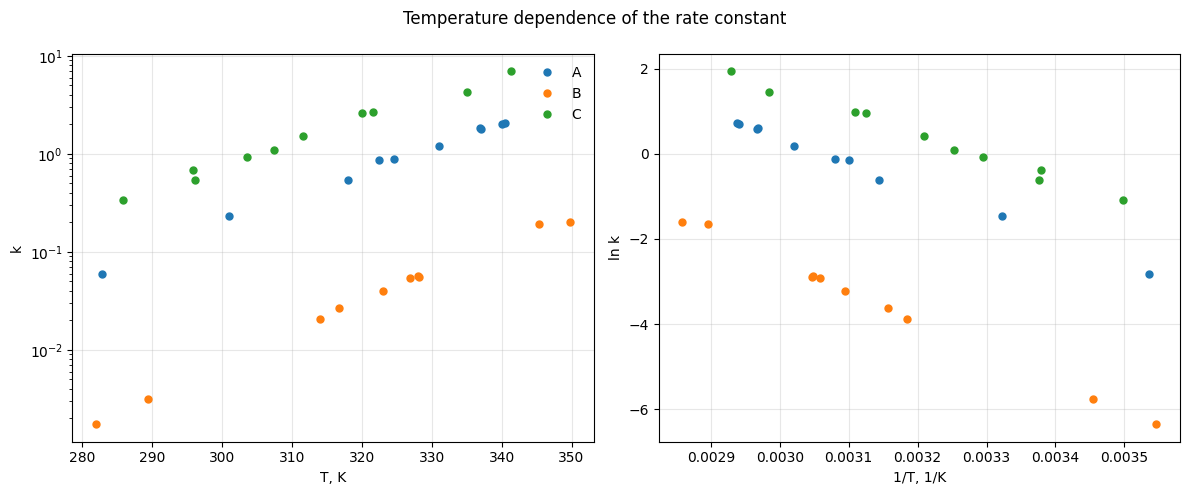

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))   # TO DO: e.g. 10, 4

# Left: k vs T
for cat, grp in df.groupby("catalyst"):
    ax1.plot(grp["temperature_K"], grp["rate_constant"], "o", ms=5, label=cat)
ax1.set_yscale("log")                # TO DO: "log"
ax1.set_xlabel("T, K")
ax1.set_ylabel("k")
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

# Right: Arrhenius
for cat, grp in df.groupby("catalyst"):
    ax2.plot(grp["inv_T"], grp["ln_k"], "o", ms=5, label=cat)    # TO DO: grp["inv_T"], grp["ln_k"]
ax2.set_xlabel("1/T, 1/K")
ax2.set_ylabel("ln k")
ax2.grid(True, alpha=0.3)

fig.suptitle("Temperature dependence of the rate constant")
fig.tight_layout()
fig.savefig("arrhenius_figure.png", dpi=300)          # TO DO: "arrhenius_figure.png", 300

In [26]:
import pandas as pd
import numpy as np

# Generate synthetic data for enzyme_kinetics.csv
rng = np.random.default_rng(0)

data_enzyme = {
    'substrate_mM': [],
    'velocity_uM_per_min': [],
    'enzyme_batch': []
}

batches = ['Batch1', 'Batch2']

for batch in batches:
    # Michaelis-Menten parameters
    if batch == 'Batch1':
        Vmax = 10.0
        Km = 1.0
    else:
        Vmax = 8.0
        Km = 1.5

    substrate_concentrations = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])

    for S in substrate_concentrations:
        true_v = (Vmax * S) / (Km + S)
        # Add Gaussian noise, ensure velocity is non-negative
        velocity = true_v + rng.normal(loc=0.0, scale=0.05 * Vmax) # Noise proportional to Vmax
        data_enzyme['substrate_mM'].append(S)
        data_enzyme['velocity_uM_per_min'].append(max(0, velocity))
        data_enzyme['enzyme_batch'].append(batch)

df_enzyme = pd.DataFrame(data_enzyme)
df_enzyme.to_csv('enzyme_kinetics.csv', index=False)
print("Generated enzyme_kinetics.csv")
print(df_enzyme.head())

Generated enzyme_kinetics.csv
   substrate_mM  velocity_uM_per_min enzyme_batch
0           0.1             0.971956       Batch1
1           0.2             1.600614       Batch1
2           0.5             3.653545       Batch1
3           1.0             5.052450       Batch1
4           2.0             6.398832       Batch1


In [24]:
import pandas as pd
import numpy as np

# Generate synthetic data for enzyme_kinetics.csv
rng = np.random.default_rng(0)

data_enzyme = {
    'substrate_mM': [],
    'velocity_uM_per_min': [],
    'enzyme_batch': []
}

batches = ['Batch1', 'Batch2']

for batch in batches:
    # Michaelis-Menten parameters
    if batch == 'Batch1':
        Vmax = 10.0
        Km = 1.0
    else:
        Vmax = 8.0
        Km = 1.5

    substrate_concentrations = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])

    for S in substrate_concentrations:
        true_v = (Vmax * S) / (Km + S)
        # Add Gaussian noise, ensure velocity is non-negative
        velocity = true_v + rng.normal(loc=0.0, scale=0.05 * Vmax) # Noise proportional to Vmax
        data_enzyme['substrate_mM'].append(S)
        data_enzyme['velocity_uM_per_min'].append(max(0, velocity))
        data_enzyme['enzyme_batch'].append(batch)

df_enzyme = pd.DataFrame(data_enzyme)
df_enzyme.to_csv('enzyme_kinetics.csv', index=False)
print("Generated enzyme_kinetics.csv")
print(df_enzyme.head())

Generated enzyme_kinetics.csv
   substrate_mM  velocity_uM_per_min enzyme_batch
0           0.1             0.971956       Batch1
1           0.2             1.600614       Batch1
2           0.5             3.653545       Batch1
3           1.0             5.052450       Batch1
4           2.0             6.398832       Batch1


In [22]:
import pandas as pd
import numpy as np

# Generate synthetic data for enzyme_kinetics.csv
rng = np.random.default_rng(0)

data_enzyme = {
    'substrate_mM': [],
    'velocity_uM_per_min': [],
    'enzyme_batch': []
}

batches = ['Batch1', 'Batch2']

for batch in batches:
    # Michaelis-Menten parameters
    if batch == 'Batch1':
        Vmax = 10.0
        Km = 1.0
    else:
        Vmax = 8.0
        Km = 1.5

    substrate_concentrations = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])

    for S in substrate_concentrations:
        true_v = (Vmax * S) / (Km + S)
        # Add Gaussian noise, ensure velocity is non-negative
        velocity = true_v + rng.normal(loc=0.0, scale=0.05 * Vmax) # Noise proportional to Vmax
        data_enzyme['substrate_mM'].append(S)
        data_enzyme['velocity_uM_per_min'].append(max(0, velocity))
        data_enzyme['enzyme_batch'].append(batch)

df_enzyme = pd.DataFrame(data_enzyme)
df_enzyme.to_csv('enzyme_kinetics.csv', index=False)
print("Generated enzyme_kinetics.csv")
print(df_enzyme.head())

Generated enzyme_kinetics.csv
   substrate_mM  velocity_uM_per_min enzyme_batch
0           0.1             0.971956       Batch1
1           0.2             1.600614       Batch1
2           0.5             3.653545       Batch1
3           1.0             5.052450       Batch1
4           2.0             6.398832       Batch1


In [14]:
import pandas as pd
import numpy as np

# Generate synthetic data for enzyme_kinetics.csv
rng = np.random.default_rng(0)

data_enzyme = {
    'substrate_mM': [],
    'velocity_uM_per_min': [],
    'enzyme_batch': []
}

batches = ['Batch1', 'Batch2']

for batch in batches:
    # Michaelis-Menten parameters
    if batch == 'Batch1':
        Vmax = 10.0
        Km = 1.0
    else:
        Vmax = 8.0
        Km = 1.5

    substrate_concentrations = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])

    for S in substrate_concentrations:
        true_v = (Vmax * S) / (Km + S)
        # Add Gaussian noise, ensure velocity is non-negative
        velocity = true_v + rng.normal(loc=0.0, scale=0.05 * Vmax) # Noise proportional to Vmax
        data_enzyme['substrate_mM'].append(S)
        data_enzyme['velocity_uM_per_min'].append(max(0, velocity))
        data_enzyme['enzyme_batch'].append(batch)

df_enzyme = pd.DataFrame(data_enzyme)
df_enzyme.to_csv('enzyme_kinetics.csv', index=False)
print("Generated enzyme_kinetics.csv")
print(df_enzyme.head())

Generated enzyme_kinetics.csv
   substrate_mM  velocity_uM_per_min enzyme_batch
0           0.1             0.971956       Batch1
1           0.2             1.600614       Batch1
2           0.5             3.653545       Batch1
3           1.0             5.052450       Batch1
4           2.0             6.398832       Batch1


### 8. Practice on your own

Repeat the whole pipeline on `enzyme_kinetics.csv` with columns
`substrate_mM`, `velocity_uM_per_min`, `enzyme_batch`.

1. Fit the Michaelis-Menten form v = Vmax*S / (Km + S) with `curve_fit`
2. Report Vmax and Km with their uncertainties for each batch
3. Make a Lineweaver-Burk plot (1/v vs 1/S) and fit it linearly
4. Compare Km from the nonlinear fit against Km from the linearised fit,
   and write one or two sentences on why they disagree

   substrate_mM  velocity_uM_per_min enzyme_batch
0           0.1             0.971956       Batch1
1           0.2             1.600614       Batch1
2           0.5             3.653545       Batch1
3           1.0             5.052450       Batch1
4           2.0             6.398832       Batch1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   substrate_mM         16 non-null     float64
 1   velocity_uM_per_min  16 non-null     float64
 2   enzyme_batch         16 non-null     object 
dtypes: float64(2), object(1)
memory usage: 516.0+ bytes
None
enzyme_batch
Batch1    8
Batch2    8
Name: count, dtype: int64

Batch Batch1:
  Nonlinear Fit: Vmax = 10.536 +/- 0.209, Km = 1.098 +/- 0.083
  Lineweaver-Burk: Vmax = 9.826, Km = 0.932

Batch Batch2:
  Nonlinear Fit: Vmax = 7.795 +/- 0.344, Km = 1.801 +/- 0.274
  Lineweaver-Burk: Vmax 

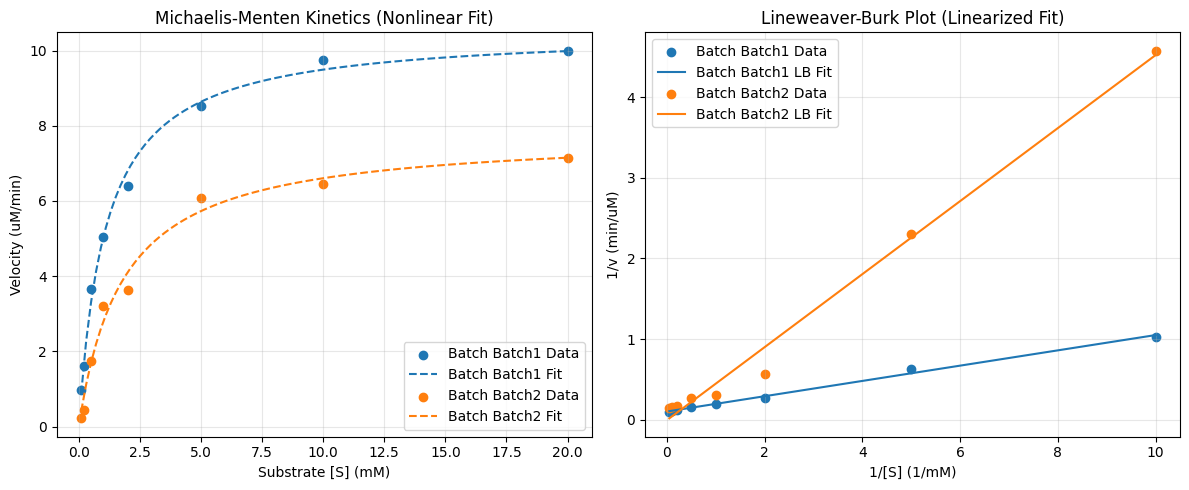


--- Comparison of Km values ---
Batch Batch1: Km (nonlinear) = 1.098, Km (Lineweaver-Burk) = 0.932
Batch Batch2: Km (nonlinear) = 1.801, Km (Lineweaver-Burk) = -80.046

Linearized plots like Lineweaver-Burk often give different parameter estimates than nonlinear fits. This is because linearization transforms the data, which can alter the error distribution. Linear regression assumes constant variance in the transformed data, which might not hold true if the original data had uniform variance. Nonlinear fitting, when properly weighted, is generally preferred as it directly minimizes errors in the original data space, leading to more accurate parameter estimates, especially in the presence of experimental noise.


In [20]:
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)        # TO DO

# TO DO: read the file, loop over enzyme_batch, fit, print, plot
path_enzyme = "enzyme_kinetics.csv"
df_enzyme = pd.read_csv(path_enzyme)

print(df_enzyme.head())
print(df_enzyme.info())
print(df_enzyme["enzyme_batch"].value_counts())

results_mm = {}

plt.figure(figsize=(12, 5))

for batch, grp in df_enzyme.groupby("enzyme_batch"):
    S_data = grp["substrate_mM"].to_numpy()
    v_data = grp["velocity_uM_per_min"].to_numpy()

    # 1. Fit the Michaelis-Menten form v = Vmax*S / (Km + S) with `curve_fit`
    # Initial guess for Vmax and Km
    p0_mm = [v_data.max(), S_data.mean()]
    try:
        popt_mm, pcov_mm = curve_fit(michaelis_menten, S_data, v_data, p0=p0_mm)
        Vmax_fit, Km_fit = popt_mm
        perr_mm = np.sqrt(np.diag(pcov_mm))

        results_mm[batch] = {"Vmax": Vmax_fit, "Vmax_err": perr_mm[0],
                             "Km": Km_fit, "Km_err": perr_mm[1]}

        # 2. Report Vmax and Km with their uncertainties for each batch
        print(f"\nBatch {batch}:")
        print(f"  Nonlinear Fit: Vmax = {Vmax_fit:.3f} +/- {perr_mm[0]:.3f}, Km = {Km_fit:.3f} +/- {perr_mm[1]:.3f}")

        # 3. Make a Lineweaver-Burk plot (1/v vs 1/S) and fit it linearly
        # Guard against zero velocity or substrate
        mask_lb = (v_data > 0) & (S_data > 0)
        inv_v = 1 / v_data[mask_lb]
        inv_S = 1 / S_data[mask_lb]

        slope_lb, intercept_lb = np.polyfit(inv_S, inv_v, 1)
        Km_lb = slope_lb / intercept_lb
        Vmax_lb = 1 / intercept_lb

        print(f"  Lineweaver-Burk: Vmax = {Vmax_lb:.3f}, Km = {Km_lb:.3f}")

        # Plotting
        plt.subplot(1, 2, 1) # Nonlinear fit
        S_smooth = np.linspace(S_data.min(), S_data.max(), 100)
        plt.scatter(S_data, v_data, label=f'Batch {batch} Data')
        plt.plot(S_smooth, michaelis_menten(S_smooth, Vmax_fit, Km_fit), '--', label=f'Batch {batch} Fit')
        plt.xlabel('Substrate [S] (mM)')
        plt.ylabel('Velocity (uM/min)')
        plt.title('Michaelis-Menten Kinetics (Nonlinear Fit)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2) # Lineweaver-Burk plot
        plt.scatter(inv_S, inv_v, label=f'Batch {batch} Data')
        plt.plot(inv_S, np.polyval([slope_lb, intercept_lb], inv_S), '-', label=f'Batch {batch} LB Fit')
        plt.xlabel('1/[S] (1/mM)')
        plt.ylabel('1/v (min/uM)')
        plt.title('Lineweaver-Burk Plot (Linearized Fit)')
        plt.legend()
        plt.grid(True, alpha=0.3)

    except RuntimeError as e:
        print(f"  Could not fit for Batch {batch}: {e}")

plt.tight_layout()
plt.show()

# 4. Compare Km from the nonlinear fit against Km from the linearised fit,
#    and write one or two sentences on why they disagree
print("\n--- Comparison of Km values ---")
for batch, res in results_mm.items():
    S_data = df_enzyme[df_enzyme["enzyme_batch"] == batch]["substrate_mM"].to_numpy()
    v_data = df_enzyme[df_enzyme["enzyme_batch"] == batch]["velocity_uM_per_min"].to_numpy()
    mask_lb = (v_data > 0) & (S_data > 0)
    inv_v = 1 / v_data[mask_lb]
    inv_S = 1 / S_data[mask_lb]
    slope_lb, intercept_lb = np.polyfit(inv_S, inv_v, 1)
    Km_lb = slope_lb / intercept_lb

    print(f"Batch {batch}: Km (nonlinear) = {res['Km']:.3f}, Km (Lineweaver-Burk) = {Km_lb:.3f}")

print("\nLinearized plots like Lineweaver-Burk often give different parameter estimates than nonlinear fits. This is because linearization transforms the data, which can alter the error distribution. Linear regression assumes constant variance in the transformed data, which might not hold true if the original data had uniform variance. Nonlinear fitting, when properly weighted, is generally preferred as it directly minimizes errors in the original data space, leading to more accurate parameter estimates, especially in the presence of experimental noise.")